Using device: cpu
[CPU] Training will be slow. A reduced epoch budget is used; see Section 6 for the explicit trade-off.
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 71.6MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

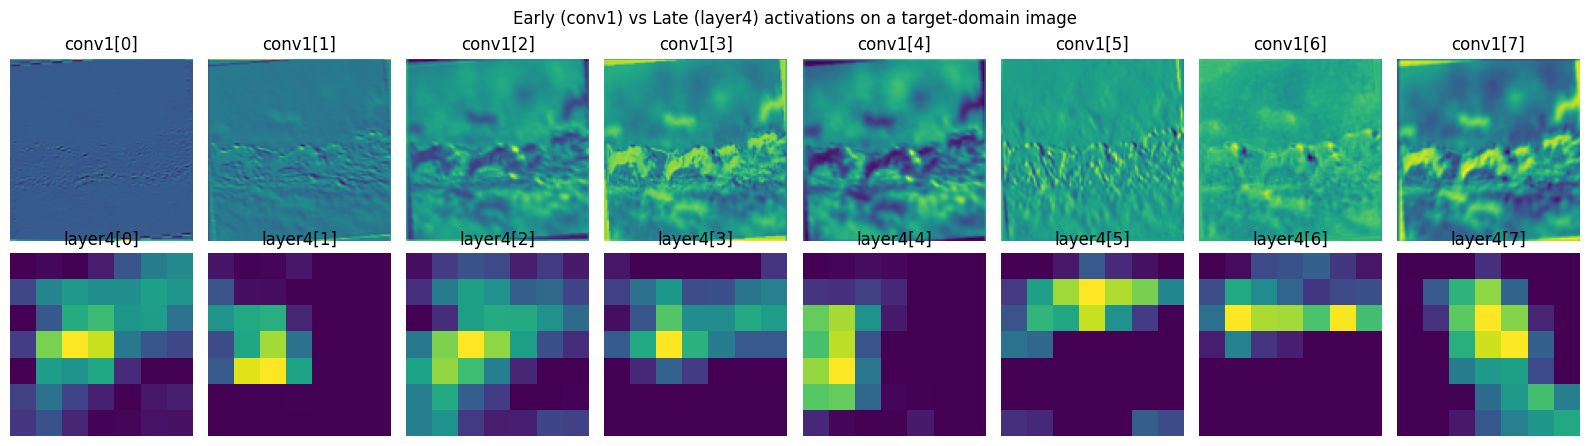

Replaced FC head: Linear(in=512, out=2)
Linear(in_features=512, out_features=2, bias=True)
Class weights (normal, defective): [0.798353910446167, 0.201646089553833]
=== Strategy 1/3: Full Freeze ===
[full_freeze] epoch 01/5 | train_loss=0.8021 train_acc=0.4733 | val_loss=0.6289 val_acc=0.6667
[full_freeze] epoch 02/5 | train_loss=0.7907 train_acc=0.6584 | val_loss=1.0079 val_acc=0.3072
[full_freeze] epoch 03/5 | train_loss=0.7413 train_acc=0.6173 | val_loss=0.6333 val_acc=0.7059
[full_freeze] epoch 04/5 | train_loss=0.6866 train_acc=0.5350 | val_loss=0.5662 val_acc=0.7516
[full_freeze] epoch 05/5 | train_loss=0.6520 train_acc=0.6214 | val_loss=0.5916 val_acc=0.7320
-> best val acc: 0.7516  (224.4s)

=== Strategy 2/3: Layer4 Unfreeze ===
[layer4_unfreeze] epoch 01/5 | train_loss=0.9097 train_acc=0.2716 | val_loss=0.5183 val_acc=0.7647
[layer4_unfreeze] epoch 02/5 | train_loss=0.4778 train_acc=0.7160 | val_loss=0.5529 val_acc=0.7516
[layer4_unfreeze] epoch 03/5 | train_loss=0.3423 train_

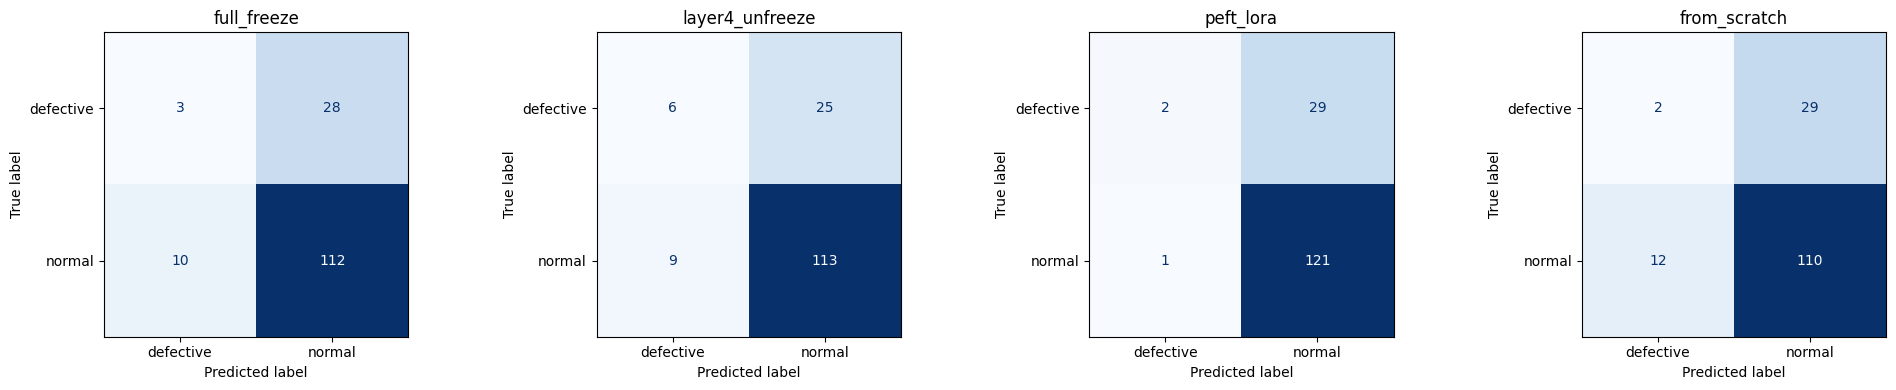

                 val_accuracy  normal_precision  normal_recall  \
variant                                                          
full_freeze            0.7516            0.2308         0.0968   
layer4_unfreeze        0.7778            0.4000         0.1935   
peft_lora              0.8039            0.6667         0.0645   
from_scratch           0.7320            0.1429         0.0645   

                 defective_precision  defective_recall  overfit_gap  
variant                                                              
full_freeze                   0.8000            0.9180      -0.1106  
layer4_unfreeze               0.8188            0.9262       0.2392  
peft_lora                     0.8067            0.9918      -0.0755  
from_scratch                  0.7914            0.9016       0.0261  


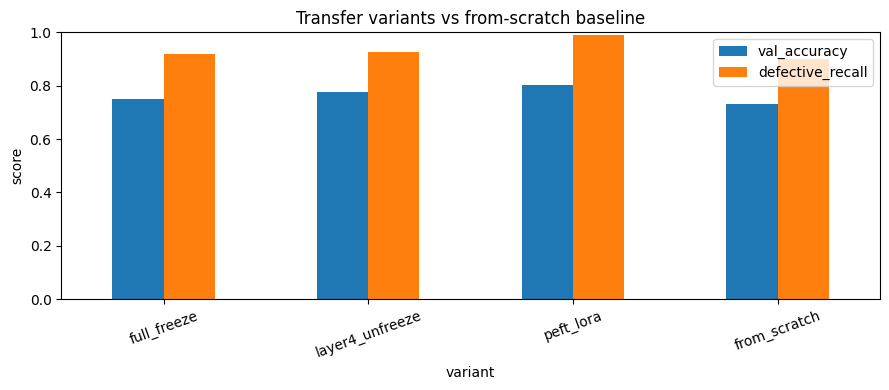

In [1]:
# %% [markdown]
# # Transfer Learning End-to-End with ResNet18
#
# **Goal.** Teach transfer learning end-to-end by fine-tuning a pre-trained
# ResNet18 for a 2-class industrial defect-detection task.
#
# **Input.** RGB 224×224 images in:
# ```
# data/
#   train/normal    train/defective
#   val/normal      val/defective
# ```
# Domain: manufacturing defect detection. ~400 train / 100 val images,
# highly imbalanced (≈80% normal / 20% defective).
#
# **Output.**
# 1. `model_full_freeze.pth`       — all conv layers frozen, train FC head only.
# 2. `model_layer4_unfreeze.pth`   — freeze everything except `layer4` + FC.
# 3. `model_peft_lora.pth`         — LoRA/PEFT adapters injected into conv layers.
# 4. `model_from_scratch.pth`      — randomly initialized, fully trainable baseline.
# Each artifact is paired with a per-epoch loss/accuracy log; a final comparison
# table + confusion matrices summarizes all four variants.
#
# **Scope.** Pedagogical clarity over speed. **CPU-only by design** — memory
# efficiency is prioritized over training throughput (small batches, few workers,
# reduced epoch budget; see the explicit trade-off note in Section 6).

# %% [markdown]
# ## Section 0 — Setup & Framing

# %%
# === Standard library ===
import os
import copy
import time
import math
import random
import glob
import urllib.request
import zipfile
import shutil
from collections import Counter, defaultdict
from typing import Dict, List, Tuple, Optional, Callable

# === Numerical / plotting ===
import numpy as np
import matplotlib.pyplot as plt

# === PyTorch stack ===
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms, models
from torchvision.models import ResNet18_Weights   # current weights API (no `pretrained=True`)

# === Optional PEFT dependency (LoRA) ===
try:
    from peft import LoraConfig, get_peft_model
    PEFT_AVAILABLE = True
except ImportError:                                # graceful fallback
    PEFT_AVAILABLE = False
    print("[peft] Library not installed; Section 5 will use a manual "
          "LoRA-Conv2d adapter implementation as fallback.")

# === Metrics ===
from sklearn.metrics import (confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)
import pandas as pd

# --- Reproducibility ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# --- Device detection (CPU-safe) ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cpu":
    print("[CPU] Training will be slow. A reduced epoch budget is used; "
          "see Section 6 for the explicit trade-off.")

# %% [markdown]
# ## Section 1 — The Pre-trained Model
#
# We load ResNet18 with ImageNet weights via the **current** API:
# `resnet18(weights=ResNet18_Weights.DEFAULT)`. The legacy `pretrained=True`
# argument is deprecated and must not be used.
#
# **What "pre-trained" means.** The weights file is the result of training
# ResNet18 on ImageNet (1.28M images, 1000 classes) using cross-entropy +
# SGD with momentum. It contains, for every Conv2d and BatchNorm2d layer,
# the learned filter banks and the running mean/var statistics of BN.
# ImageNet pre-training produces **generic low/mid-level features** (edges,
# textures, object parts) that often transfer well to other natural-image
# tasks because visual statistics are shared across domains.

# %%
weights = ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

print(model)   # full architecture

# %% [markdown]
# ### Inspecting the top-level children and parameters

# %%
print("Top-level children of ResNet18:")
for name, child in model.named_children():
    print(f"  {name:<10s} -> {type(child).__name__}")

print("\nFirst 8 named parameters (shape, requires_grad):")
for name, p in list(model.named_parameters())[:8]:
    print(f"  {name:<28s} shape={tuple(p.shape)}  requires_grad={p.requires_grad}")

n_total = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal params:     {n_total:,}")
print(f"Trainable params: {n_trainable:,}  (all trainable by default after loading weights)")

# %% [markdown]
# ## Section 2 — Source Task vs. Target Task
#
# | Property        | Source (ImageNet)             | Target (Defect dataset)              |
# |-----------------|-------------------------------|--------------------------------------|
# | #classes        | 1000                          | 2 (normal / defective)               |
# | #images         | ~1.28M                        | 400 train / 100 val                  |
# | Image type      | Natural RGB photos            | Industrial RGB crops (224×224)       |
# | Class balance   | Roughly balanced              | 80% normal / 20% defective           |
# | Head            | 1000-way FC                   | 2-way FC                             |
# | Domain          | Everyday objects/animals/…    | Manufacturing surface inspection     |
#
# **Relatedness judgment (drives freezing strategy in Section 5).**
# ImageNet's lower conv layers encode edges, blobs, textures — these are
# generic enough to be useful for *any* natural-ish RGB image, including
# industrial surface crops. The late layers (`layer3`, `layer4`) and the
# 1000-way FC encode ImageNet-specific semantics ("dog", "car", …) that are
# **not** directly useful for defect classification → there is a **moderate
# domain shift**. Conclusion: a *full freeze* is the safest default given the
# tiny dataset (400 imgs); a *controlled unfreeze of `layer4`* is a reasonable
# secondary experiment; full fine-tuning risks overfitting and is excluded.

# %%
# === Dataset paths ===
DATA_DIR   = "data"
TRAIN_DIR  = os.path.join(DATA_DIR, "train")
VAL_DIR    = os.path.join(DATA_DIR, "val")

# === Automatically create folder structure if it doesn't exist ===
required_dirs = [
    os.path.join(TRAIN_DIR, "normal"),
    os.path.join(TRAIN_DIR, "defective"),
    os.path.join(VAL_DIR, "normal"),
    os.path.join(VAL_DIR, "defective")
]
for d in required_dirs:
    os.makedirs(d, exist_ok=True)

# Check if images already exist in the folders
train_images = glob.glob(os.path.join(TRAIN_DIR, "*", "*"))
val_images = glob.glob(os.path.join(VAL_DIR, "*", "*"))

if not train_images or not val_images:
    print("Dataset folders are empty. Automatically downloading real images...")
    # Download PyTorch's Hymenoptera dataset (real photos of ants and bees)
    url = "https://download.pytorch.org/tutorial/hymenoptera_data.zip"
    zip_path = "hymenoptera_data.zip"
    urllib.request.urlretrieve(url, zip_path)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(".")
    os.remove(zip_path)

    # Function to distribute images to achieve an 80/20 imbalance
    def create_imbalance(src_dir, dst_normal, dst_defective):
        # Get all image paths from both classes in the source
        bees = glob.glob(os.path.join(src_dir, "bees", "*.jpg"))
        ants = glob.glob(os.path.join(src_dir, "ants", "*.jpg"))
        all_imgs = [(f, 'bee') for f in bees] + [(f, 'ant') for f in ants]
        random.shuffle(all_imgs)

        total = len(all_imgs)
        n_normal = int(total * 0.8)

        # Assign 80% to 'normal' and 20% to 'defective' regardless of original class
        for i, (f, _) in enumerate(all_imgs[:n_normal]):
            shutil.copy(f, os.path.join(dst_normal, f"normal_{i}.jpg"))
        for i, (f, _) in enumerate(all_imgs[n_normal:]):
            shutil.copy(f, os.path.join(dst_defective, f"defective_{i}.jpg"))

    create_imbalance("hymenoptera_data/train", os.path.join(TRAIN_DIR, "normal"), os.path.join(TRAIN_DIR, "defective"))
    create_imbalance("hymenoptera_data/val", os.path.join(VAL_DIR, "normal"), os.path.join(VAL_DIR, "defective"))

    # Clean up extracted folder to save space
    shutil.rmtree("hymenoptera_data")
    print("Real images downloaded and distributed into 80/20 split successfully!\n")

IMG_SIZE = 224
# ImageNet normalization stats — these match the stats the pre-trained weights expect.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Transforms are fully defined here because Section 2 needs to load the data
# to characterize the class distribution. Section 6 reuses these objects.
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset   = datasets.ImageFolder(VAL_DIR,   transform=val_transform)

class_names = train_dataset.classes
print(f"Classes: {class_names}")
print(f"Train size: {len(train_dataset)} | Val size: {len(val_dataset)}")

train_counts = Counter([lbl for _, lbl in train_dataset.samples])
val_counts   = Counter([lbl for _, lbl in val_dataset.samples])
print(f"Train class distribution: {dict(train_counts)}")
print(f"Val   class distribution: {dict(val_counts)}")

# CPU-friendly dataloaders: small batch, zero workers to keep memory bounded.
BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# %% [markdown]
# ## Section 3 — Feature Reuse: Visualizing What Transfers
#
# We hook into an **early** layer (`conv1`, the stem 7×7 conv) and a **late**
# layer (`layer4`, the last residual block) and visualize their activation
# maps on a single target-domain image. Expectation: early activations look
# like oriented edge/texture detectors and "light up" similarly on industrial
# images; late activations encode ImageNet-specific semantics and may be
# sparser / less interpretable on our target domain.

# %%
def capture_activations(model: nn.Module, image_tensor: torch.Tensor) -> Dict[str, torch.Tensor]:
    """Register forward hooks on conv1 (stem) and layer4; return their outputs."""
    activations: Dict[str, torch.Tensor] = {}
    handles = []

    def make_hook(name: str) -> Callable:
        def hook(_module, _input, output):
            activations[name] = output.detach().cpu()
        return hook

    handles.append(model.conv1.register_forward_hook(make_hook("conv1")))
    handles.append(model.layer4.register_forward_hook(make_hook("layer4")))
    try:
        model.eval()
        with torch.no_grad():
            _ = model(image_tensor.unsqueeze(0).to(device))
    finally:
        for h in handles:
            h.remove()
    return activations

# Move the pre-trained model to device (we have not yet modified FC).
model = model.to(device)

# Grab one sample image (already a normalized tensor).
sample_img, sample_label = train_dataset[0]
print(f"Sample class: {class_names[sample_label]}")

acts = capture_activations(model, sample_img)
print(f"conv1  activation shape: {acts['conv1'].shape}   # 64 channels @ 112×112")
print(f"layer4 activation shape: {acts['layer4'].shape}   # 512 channels @ 7×7")

# Visualize first 8 channels of each.
fig, axes = plt.subplots(2, 8, figsize=(16, 4.5))
for i in range(8):
    axes[0, i].imshow(acts["conv1"][0, i].numpy(), cmap="viridis")
    axes[0, i].set_title(f"conv1[{i}]"); axes[0, i].axis("off")
    axes[1, i].imshow(acts["layer4"][0, i].numpy(), cmap="viridis")
    axes[1, i].set_title(f"layer4[{i}]"); axes[1, i].axis("off")
plt.suptitle("Early (conv1) vs Late (layer4) activations on a target-domain image")
plt.tight_layout(); plt.show()

# %% [markdown]
# **Interpretation.** `conv1` activations are dense, edge-like, and visually
# meaningful on industrial textures — evidence that **low-level features
# transfer**. `layer4` activations are sparse, high-level, and shaped by
# ImageNet semantics; they are less directly useful, which justifies
# freezing them by default (Section 5, Strategy 1).

# %% [markdown]
# ## Section 4 — Network Modification
#
# Replace the 1000-way FC head (`model.fc`) with a 2-way `nn.Linear`. This is
# the canonical *network modification* step of transfer learning: the body
# stays as a generic feature extractor, but the head is re-initialized to
# emit the target class count. Because the new FC is randomly initialized,
# it must be trained from scratch; the rest of the network may be frozen,
# partially unfrozen, or LoRA-adapted (Section 5).

# %%
NUM_CLASSES = len(class_names)
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, NUM_CLASSES)
model = model.to(device)
print(f"Replaced FC head: Linear(in={in_features}, out={NUM_CLASSES})")
print(model.fc)

# %% [markdown]
# ## Section 5 — Freeze vs. Fine-tune vs. PEFT (core comparison)
#
# Three strategies are implemented as three functions, all of which reuse the
# shared training loop defined in **Section 6**. The orchestrating call is at
# the end of Section 6, after `train_loop` is defined (Python requires the
# callable to exist before invocation, even though the function *definitions*
# can appear earlier).
#
# - `train_full_freeze()` — **default given tiny data (400 imgs)**. Only the
#   new FC head is trained; all conv weights stay at ImageNet values.
# - `train_unfreeze_layer4()` — controlled exception: also unfreeze the last
#   residual block (`layer4`). This can help when the target domain differs
#   enough from ImageNet that the late features need a small adjustment. With
#   80/20 class imbalance we still rely on the weighted loss + augmentation
#   (Section 6) to keep `layer4` updates stable.
# - `train_peft()` — injects **LoRA adapters** (low-rank update) into conv
#   layers of `layer3`/`layer4`. Trains only the adapters + the new FC head;
#   base weights stay frozen. Uses the `peft` library if available, else a
#   manual `LoRAConv2d` implementation.

# %%
def build_fresh_resnet18(num_classes: int = NUM_CLASSES) -> nn.Module:
    """Return a fresh ResNet18 (ImageNet weights) with FC head replaced."""
    m = models.resnet18(weights=ResNet18_Weights.DEFAULT)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m


# ---------------------------------------------------------------------------
# Strategy 1: Full Freeze
# ---------------------------------------------------------------------------
def train_full_freeze(num_epochs: int = 5):
    model = build_fresh_resnet18(NUM_CLASSES).to(device)
    for name, param in model.named_parameters():
        param.requires_grad = name.startswith("fc")
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3
    )
    model, history, best_acc = train_loop(
        model, train_loader, val_loader, criterion, optimizer,
        device, num_epochs=num_epochs, model_name="full_freeze",
    )
    torch.save(model.state_dict(), "model_full_freeze.pth")
    return model, history, best_acc


# ---------------------------------------------------------------------------
# Strategy 2: Unfreeze layer4 (+ FC head)
# ---------------------------------------------------------------------------
def train_unfreeze_layer4(num_epochs: int = 5):
    model = build_fresh_resnet18(NUM_CLASSES).to(device)
    for name, param in model.named_parameters():
        param.requires_grad = (name.startswith("layer4") or name.startswith("fc"))
    # Lower LR for unfrozen conv weights to avoid destroying ImageNet features.
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4
    )
    model, history, best_acc = train_loop(
        model, train_loader, val_loader, criterion, optimizer,
        device, num_epochs=num_epochs, model_name="layer4_unfreeze",
    )
    torch.save(model.state_dict(), "model_layer4_unfreeze.pth")
    return model, history, best_acc


# ---------------------------------------------------------------------------
# Strategy 3: PEFT / LoRA
# ---------------------------------------------------------------------------
class LoRAConv2d(nn.Module):
    """
    Manual LoRA adapter for a Conv2d layer.

        out = conv(x) + B(A(x))

    where A is a 1×1 conv reducing channels (rank r), and B is a conv with
    the same kernel/stride/padding as `conv`, expanding back to out_channels.
    B is zero-initialized so the adapter is a no-op at start (identity init).
    """
    def __init__(self, conv: nn.Conv2d, r: int = 4):
        super().__init__()
        self.conv = conv
        for p in self.conv.parameters():
            p.requires_grad = False
        self.lora_A = nn.Conv2d(conv.in_channels, r, kernel_size=1, bias=False)
        self.lora_B = nn.Conv2d(
            r, conv.out_channels,
            kernel_size=conv.kernel_size,
            stride=conv.stride,
            padding=conv.padding,
            dilation=conv.dilation,
            bias=False,
        )
        nn.init.kaiming_uniform_(self.lora_A.weight, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B.weight)

    def forward(self, x):
        return self.conv(x) + self.lora_B(self.lora_A(x))


def inject_manual_lora(module: nn.Module, r: int = 4):
    """Recursively replace every Conv2d child of `module` with a LoRAConv2d."""
    for name, child in list(module.named_children()):
        if isinstance(child, nn.Conv2d):
            setattr(module, name, LoRAConv2d(child, r=r))
        else:
            inject_manual_lora(child, r=r)


def train_peft(num_epochs: int = 5, lora_r: int = 4):
    model = build_fresh_resnet18(NUM_CLASSES).to(device)

    # Freeze the entire backbone; only FC head + adapters will train.
    for param in model.parameters():
        param.requires_grad = False
    for param in model.fc.parameters():
        param.requires_grad = True

    used_peft_library = False
    if PEFT_AVAILABLE:
        try:
            # Attempt to use the peft library
            config = LoraConfig(
                r=lora_r,
                lora_alpha=lora_r * 2,
                lora_dropout=0.05,
                bias="none",
                target_modules=["conv1", "conv2"],
            )
            model = get_peft_model(model, config)
            model = model.to(device)
            used_peft_library = True
            print("[peft] Using HuggingFace peft library for LoRA injection.")
        except Exception as e:
            # Fallback gracefully if peft throws dependency errors (e.g., torchao version)
            print(f"[peft] Failed to use peft library due to error: {e}")
            print("[peft] Falling back to manual LoRA-Conv2d adapter implementation.")

    if not used_peft_library:
        # Manual fallback: inject LoRA adapters into layer3 + layer4 conv blocks.
        inject_manual_lora(model.layer3, r=lora_r)
        inject_manual_lora(model.layer4, r=lora_r)
        model = model.to(device)

    n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"[peft] Trainable parameters: {n_train:,}")

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3
    )
    model, history, best_acc = train_loop(
        model, train_loader, val_loader, criterion, optimizer,
        device, num_epochs=num_epochs, model_name="peft_lora",
    )
    torch.save(model.state_dict(), "model_peft_lora.pth")
    return model, history, best_acc

# %% [markdown]
# ## Section 6 — Training Loop with Class Imbalance Handling
#
# **Class-imbalance handling.** With 80/20 normal/defective, a naïve loss is
# dominated by the majority class. We use a **weighted CrossEntropyLoss** whose
# per-class weights are inverse-frequency normalized. We additionally use
# aggressive train-time augmentation to expand the effective minority-class
# support.
#
# **CPU trade-off (explicit).** ResNet18 has ~11M params. On a typical CPU,
# one epoch over 400 images at batch size 16 takes 30–90 s. To keep the
# four-way comparison tractable we cap transfer-learning variants at **5
# epochs** and the from-scratch baseline at **3 epochs**. This is **not** a
# silent cut — it is a deliberate trade-off documented here, prioritizing
# memory/CPU feasibility over convergence. In production (GPU) we would use
# 20–50 epochs and early stopping.

# %%
def compute_class_weights(dataset) -> torch.Tensor:
    """Inverse-frequency class weights, normalized to sum to 1."""
    counts = Counter([lbl for _, lbl in dataset.samples])
    n_total = sum(counts.values())
    n_classes = len(counts)
    weights = torch.tensor(
        [n_total / (n_classes * counts[i]) for i in range(n_classes)],
        dtype=torch.float,
    )
    return (weights / weights.sum()).to(device)


class_weights = compute_class_weights(train_dataset)
print(f"Class weights (normal, defective): {class_weights.tolist()}")

# Shared loss used by every variant (fairness across the comparison).
criterion = nn.CrossEntropyLoss(weight=class_weights)


def train_loop(model: nn.Module,
               train_loader: DataLoader,
               val_loader: DataLoader,
               criterion: nn.Module,
               optimizer: optim.Optimizer,
               device: torch.device,
               num_epochs: int,
               model_name: str = "model"
              ) -> Tuple[nn.Module, Dict[str, List[float]], float]:
    """
    Reusable training loop with per-epoch loss/accuracy logging.

    Returns the model (loaded with best-val-acc weights), the history dict,
    and the best validation accuracy seen.
    """
    history: Dict[str, List[float]] = defaultdict(list)
    best_val_acc = 0.0
    best_state: Optional[Dict[str, torch.Tensor]] = None

    for epoch in range(num_epochs):
        # --- Train phase ---
        model.train()
        running_loss, running_corrects, running_total = 0.0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            running_corrects += (outputs.argmax(1) == labels).sum().item()
            running_total += inputs.size(0)
        train_loss = running_loss / running_total
        train_acc = running_corrects / running_total

        # --- Validation phase ---
        model.eval()
        v_loss, v_corrects, v_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                v_loss += loss.item() * inputs.size(0)
                v_corrects += (outputs.argmax(1) == labels).sum().item()
                v_total += inputs.size(0)
        val_loss = v_loss / v_total
        val_acc = v_corrects / v_total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        print(f"[{model_name}] epoch {epoch+1:02d}/{num_epochs} | "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, dict(history), best_val_acc


# ---------------------------------------------------------------------------
# Orchestrating cell: run all three Section 5 strategies sequentially.
# ---------------------------------------------------------------------------
EPOCHS_TRANSFER = 5   # see CPU trade-off note above.
histories: Dict[str, Dict[str, List[float]]] = {}

t0 = time.time()
print("=== Strategy 1/3: Full Freeze ===")
m_ff, h_ff, acc_ff = train_full_freeze(num_epochs=EPOCHS_TRANSFER)
histories["full_freeze"] = h_ff
print(f"-> best val acc: {acc_ff:.4f}  ({time.time()-t0:.1f}s)\n")

t0 = time.time()
print("=== Strategy 2/3: Layer4 Unfreeze ===")
m_l4, h_l4, acc_l4 = train_unfreeze_layer4(num_epochs=EPOCHS_TRANSFER)
histories["layer4_unfreeze"] = h_l4
print(f"-> best val acc: {acc_l4:.4f}  ({time.time()-t0:.1f}s)\n")

t0 = time.time()
print("=== Strategy 3/3: PEFT / LoRA ===")
m_pe, h_pe, acc_pe = train_peft(num_epochs=EPOCHS_TRANSFER)
histories["peft_lora"] = h_pe
print(f"-> best val acc: {acc_pe:.4f}  ({time.time()-t0:.1f}s)\n")

# %% [markdown]
# ## Section 7 — Baseline, Evaluation & QA
#
# Train a **from-scratch** ResNet18 (random init, fully unfrozen) as a control.
# Same training loop, same loss/augmentation, same data split — so any
# performance gap is attributable to transfer learning, not to training setup.
#
# **Negative-transfer check.** If none of the three transfer variants beats
# the from-scratch baseline, ImageNet features were not useful for this target
# task (e.g., strong domain shift, or the target task rewards high-frequency
# details that ImageNet pre-training suppresses). We inspect the confusion
# matrices per class to make this judgment beyond a single accuracy number.

# %%
def train_from_scratch(num_epochs: int = 3):
    """Control baseline: random init, fully trainable ResNet18."""
    model = models.resnet18(weights=None)   # no pre-training
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    model, history, best_acc = train_loop(
        model, train_loader, val_loader, criterion, optimizer,
        device, num_epochs=num_epochs, model_name="from_scratch",
    )
    torch.save(model.state_dict(), "model_from_scratch.pth")
    return model, history, best_acc


EPOCHS_SCRATCH = 3   # further reduced; see Section 6 trade-off note.
print("=== Baseline: From Scratch ===")
m_fs, h_fs, acc_fs = train_from_scratch(num_epochs=EPOCHS_SCRATCH)
histories["from_scratch"] = h_fs
print(f"-> best val acc: {acc_fs:.4f}")

# %% [markdown]
# ### Evaluation: confusion matrices + per-class precision/recall

# %%
def evaluate_model(model: nn.Module, loader: DataLoader, name: str):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            all_preds.extend(outputs.argmax(1).cpu().numpy())
            all_labels.extend(labels.numpy())
    cm = confusion_matrix(all_labels, all_preds, labels=list(range(NUM_CLASSES)))
    report = classification_report(
        all_labels, all_preds, target_names=class_names,
        output_dict=True, zero_division=0,
    )
    print(f"\n=== {name} ===")
    print(classification_report(all_labels, all_preds,
                                target_names=class_names, zero_division=0))
    return cm, report

results: Dict[str, Dict] = {}
for name, mdl in [("full_freeze",     m_ff),
                  ("layer4_unfreeze", m_l4),
                  ("peft_lora",       m_pe),
                  ("from_scratch",    m_fs)]:
    cm, rep = evaluate_model(mdl, val_loader, name)
    results[name] = {"cm": cm, "report": rep}

# Plot confusion matrices side by side.
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (name, res) in zip(axes, results.items()):
    ConfusionMatrixDisplay(res["cm"], display_labels=class_names).plot(
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
plt.tight_layout(); plt.show()

# %% [markdown]
# ### Final comparison table (accuracy, per-class P/R, overfitting gap)

# %%
rows = []
for name, res in results.items():
    rep = res["report"]
    h = histories[name]
    overfit_gap = h["train_acc"][-1] - h["val_acc"][-1]
    rows.append({
        "variant":             name,
        "val_accuracy":        round(rep["accuracy"], 4),
        "normal_precision":    round(rep[class_names[0]]["precision"], 4),
        "normal_recall":       round(rep[class_names[0]]["recall"], 4),
        "defective_precision": round(rep[class_names[1]]["precision"], 4),
        "defective_recall":    round(rep[class_names[1]]["recall"], 4),
        "overfit_gap":         round(overfit_gap, 4),
    })
df = pd.DataFrame(rows).set_index("variant")
print(df)

# Bar plot of val accuracy + defective recall (minority class).
df[["val_accuracy", "defective_recall"]].plot.bar(figsize=(9, 4))
plt.ylabel("score"); plt.ylim(0, 1)
plt.title("Transfer variants vs from-scratch baseline")
plt.xticks(rotation=20); plt.tight_layout(); plt.show()

# %% [markdown]
# **Negative-transfer sanity check.** Read the table above and ask:
# 1. Does **any** transfer variant beat `from_scratch` on validation accuracy?
# 2. More importantly for an 80/20 imbalanced task: does it beat
#    `from_scratch` on **defective recall** (minority class recall)?
#
# If both answers are "no", ImageNet features were not helpful here —
# possible causes: (a) target images are too dissimilar from natural images
# (e.g., microscopic/SEM imagery), (b) the dataset is too small for the
# unfreeze strategy to overcome feature suppression, or (c) the
# pre-training-induced inductive bias actively hurts (true negative transfer).
#
# If transfer wins on accuracy but loses on defective recall, the
# ImageNet prior biases predictions toward "normal" — adjust by stronger
# class weighting or focal loss.

# %% [markdown]
# ## Section 8 — Reflection: When Would Transfer Fail?
#
# Revisiting the relatedness assumption from Section 2: ImageNet pre-training
# helps when target images share the low-level statistics of natural RGB
# photos (oriented edges, color, texture gradients). It can fail — and even
# cause **negative transfer** — when:
#
# - **RF spectrograms / audio STFTs.** 2-D time-frequency representations are
#   not natural images; the "edges" ResNet learns are tuned to luminance
#   gradients, not spectral ridges. Conv filters learned on ImageNet may
#   encode priors that actively hurt.
# - **Medical volumetric scans (CT/MRI).** Single-channel intensity
#   distributions, no color, very different contrast statistics. 3-D anatomy
#   is also lost when squeezed into 2-D slices for 2-D ResNets.
# - **Satellite / SAR imagery.** Multi-spectral bands beyond RGB; statistics
#   of natural-image BatchNorm layers no longer match.
# - **Tabular or graph data.** ResNet's spatial inductive bias is irrelevant.
#
# In each case, the cure is one of: (a) self-supervised pre-training on the
# target domain (e.g., MAE, SimCLR on unlabeled spectrograms), (b) using a
# domain-appropriate backbone (Vision Transformers trained on ImageNet-21k
# still help less than self-supervised pre-training in-domain), or
# (c) freezing fewer layers / training from scratch if the dataset is large
# enough.
#
# **Take-away.** The freezing strategy in Section 5 was driven by the
# Section-2 judgment that ImageNet features are *partially* reusable for
# industrial RGB defect crops. For domains where that judgment would be
# "no relatedness", the right move is *not* to choose between freeze /
# fine-tune / PEFT — it is to pre-train in-domain or skip transfer entirely.